# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme (Lecture 3) was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck. But do then of course ask us for help in the lab and on EdDiscussion.
_______________________________________________________________________________

# Set up

In [2]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 16.5 MB/s eta 0:00:00


In [3]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog-761-rata') #<- Remember to change this to your own project's name!

In [59]:
# Import other libs
import geemap
import geopandas as gpd
import zipfile
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import rasterio
import numpy.ma as ma

# Define Area of Interest (AOI)

In [5]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [6]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi))

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

In [6]:
# Answer to this question in the answer proforma

In [7]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [8]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi) # For 2020

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

In [9]:
# Answer to this question in the answer proforma

In [9]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)

Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [10]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3156000077724457
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)

In [12]:
# Answer to this question in the answer proforma

We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [11]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [12]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [13]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [14]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)

In [ ]:
# Answer to this question in the answer proforma

Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       20        0        5        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        38        0      117        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         4        0        8        0       28        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)
_______________________________________________________________________________


In [16]:
# Exercise 5 - modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020.

# Defining a function that can return a composite for any year
def get_s2_composite(year, aoi):
    start = f'{year}-01-01'
    end = f'{year}-12-31'
    s2_year = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterBounds(aoi)
               .filterDate(start, end)
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
               .map(mask_s2_clouds)
               .median()
               .clip(aoi))
    return s2_year

#Composites for the years required
s2_2018 = get_s2_composite(2018, aoi)
s2_2022 = get_s2_composite(2022, aoi)
s2_2024 = get_s2_composite(2024, aoi)

In [17]:
# Classifying each composite using the 2020 trained classifier
classified_2018 = s2_2018.select(bands).classify(classifier)
classified_2022 = s2_2022.select(bands).classify(classifier)
classified_2024 = s2_2024.select(bands).classify(classifier)

In [18]:
# Computing the 2020 test accuracy
test_classified = test.classify(classifier, 'predicted')
y_true_test, y_pred_test = fc_to_lists(test_classified, 'Map_remapped', 'predicted')

test_accuracy = accuracy_score(y_true_test, y_pred_test)
n_test = len(y_true_test)  # Sample size

print(f"2020 Test Accuracy: {test_accuracy:.2%}")
print(f"Test set size: {n_test}")
print("\nFull classification report:")
print(classification_report(y_true_test, y_pred_test, labels=list(range(1, 11))))

2020 Test Accuracy: 91.30%
Test set size: 460

Full classification report:
              precision    recall  f1-score   support

           1       0.81      0.91      0.85       106
           2       0.00      0.00      0.00         0
           3       0.84      0.75      0.80        85
           4       0.00      0.00      0.00         1
           5       0.76      0.80      0.78        20
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         0
           8       1.00      1.00      1.00       245
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         0

    accuracy                           0.91       460
   macro avg       0.34      0.35      0.34       460
weighted avg       0.91      0.91      0.91       460



In [19]:
# Converting the classified images into arrays
arr_2018 = geemap.ee_to_numpy(classified_2018, region=aoi, scale=30)
arr_2022 = geemap.ee_to_numpy(classified_2022, region=aoi, scale=30)
arr_2024 = geemap.ee_to_numpy(classified_2024, region=aoi, scale=30)

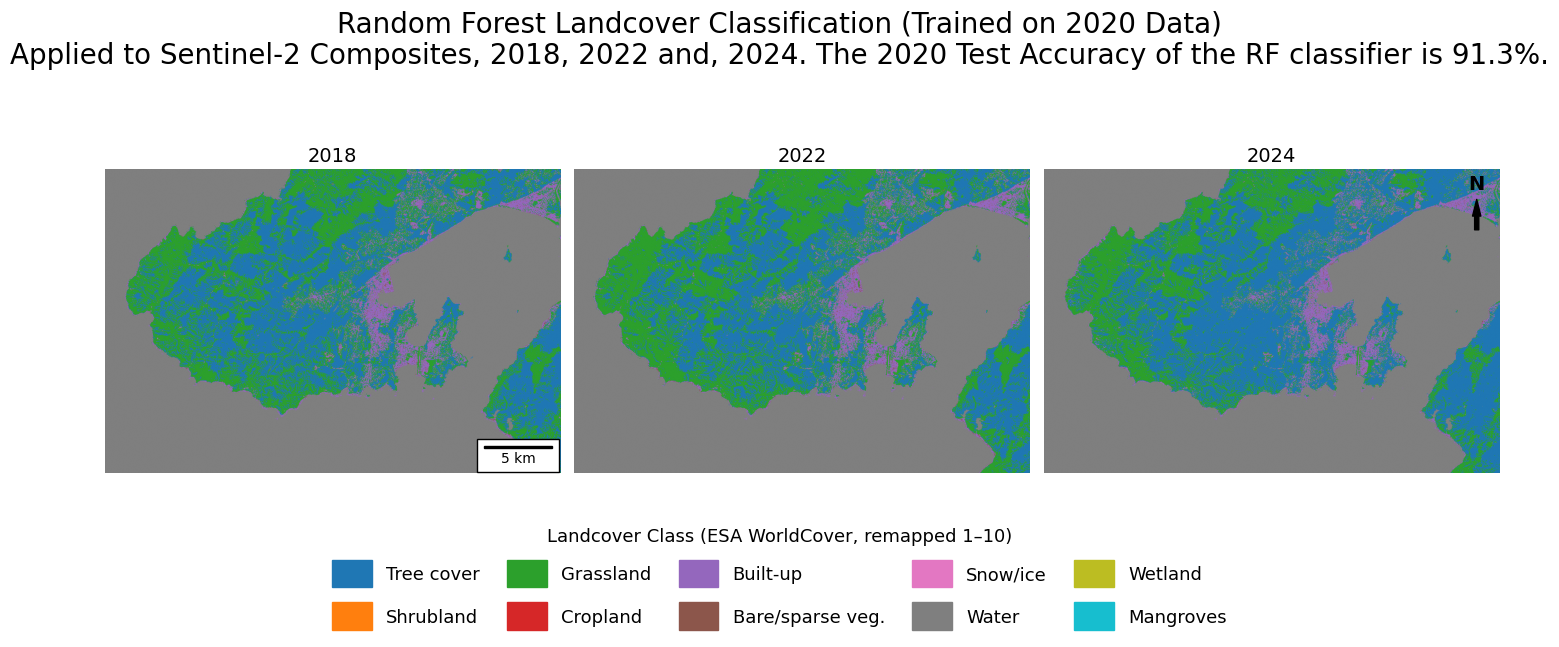

In [20]:
# Plotting!
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
cmap = ListedColormap(palette)
bounds = np.arange(0.5, 11.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))

years = [2018, 2022, 2024]
arrays = [arr_2018, arr_2022, arr_2024]

for ax, year, arr in zip(axes, years, arrays):
    im = ax.imshow(arr.squeeze(), cmap=cmap, norm=norm)
    ax.set_title(f'{year}', fontsize=14)
    ax.axis('off')

fig.suptitle(
    'Random Forest Landcover Classification (Trained on 2020 Data)\n'
    f'Applied to Sentinel-2 Composites, 2018, 2022 and, 2024. The 2020 Test Accuracy of the RF classifier is {test_accuracy:.1%}.',
    fontsize=20, y=0.98
)

# Legend for classes
class_names = ['Tree cover', 'Shrubland', 'Grassland', 'Cropland', 'Built-up',
               'Bare/sparse veg.', 'Snow/ice', 'Water', 'Wetland', 'Mangroves']
legend_patches = [mpatches.Patch(color=palette[i], label=class_names[i]) for i in range(10)]
legend = fig.legend(
    handles=legend_patches, loc='lower center', ncol=5,
    bbox_to_anchor=(0.5, 0.0),  # was -0.06
    frameon=False, fontsize=13,
    title='Landcover Class (ESA WorldCover, remapped 1–10)',
    handlelength=2.2, handleheight=2.0, labelspacing=0.8, columnspacing=1.5
)
legend.get_title().set_fontsize(13)

# North arrow
axes[-1].annotate('', xy=(0.95, 0.90), xycoords='axes fraction',
                   xytext=(0.95, 0.80), textcoords='axes fraction',
                   arrowprops=dict(facecolor='black', width=3, headwidth=6))
axes[-1].text(0.95, 0.92, 'N', transform=axes[-1].transAxes,
              fontsize=14, fontweight='bold', ha='center', va='bottom')

km_per_pixel = 30 / 1000
bar_length_km = 5
bar_length_px = bar_length_km / km_per_pixel
scalebar = AnchoredSizeBar(
    axes[0].transData, bar_length_px, f'{bar_length_km} km',
    loc='lower right', pad=0.5, color='black', frameon=True,
    size_vertical=arr_2018.shape[0] * 0.008,
    fontproperties=fm.FontProperties(size=10)
)
axes[0].add_artist(scalebar)

plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.03)
plt.savefig('wellington_landcover_rf_multiyear.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Checking that everything is correct

stats_2018 = s2_2018.select(bands).reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi, scale=100, maxPixels=1e9).getInfo()
stats_2022 = s2_2022.select(bands).reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi, scale=100, maxPixels=1e9).getInfo()
stats_2024 = s2_2024.select(bands).reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi, scale=100, maxPixels=1e9).getInfo()

print("2018 mean band values:", stats_2018)
print("2022 mean band values:", stats_2022)
print("2024 mean band values:", stats_2024)
np.unique(arr, return_counts=True)

# Everything makes sense! Of the 10 possible landcover classes, the classified 2018 output contains only 6,
# with water (class 8) alone accounting for approximately 54% of classified pixels (420,162 of ~827,700),
# while classes 2, 4, 7, and 10 (each represented by very few training samples) do not appear in the output at all.

2018 mean band values: {'B2': 0.04006448479561276, 'B3': 0.0472854303651651, 'B4': 0.029696973543885796, 'B8': 0.15685058891537967}
2022 mean band values: {'B2': 0.041977914783079544, 'B3': 0.04997890977364526, 'B4': 0.0337388801574095, 'B8': 0.1571255973938852}
2024 mean band values: {'B2': 0.03652459629321237, 'B3': 0.04180471918382445, 'B4': 0.028263784701404764, 'B8': 0.13219759819097027}


(array([1, 3, 5, 6, 8, 9], dtype=int32),
 array([225225, 141868,  38765,   1612, 420162,     70]))

# SVMs Applied to Satellite Data

In [22]:
# Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

# Evaluate test performance
test_matrix = test_classified.errorMatrix(class_property, 'classification')
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))
print("\nClassification Report:")
print(report)

Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       229        0       20        0        5        0        0   
Actual 20         1        0        1        0        0        0        0   
Actual 30        38        0      117        0        3        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         4        0        8        0       28        3        0   
Actual 60         1        0        1        0        4        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         0        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



In [26]:
# Extracting the data
zip_path = "/content/lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("lcdb")

# Listing what got extracted
import os
print(os.listdir("lcdb"))


['lcdb-v50-legend-symbology-lyrx.lyrx', 'lcdb-v50-land-cover-database-version-50-mainland-new-zealand.dbf', 'lcdb-v50-cover-class-change-summary-2012-2018.xlsx', 'lcdb-user-guide-1-new-versionspdf.pdf', 'lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp', 'lcdb-v50-cover-class-change-summary-1996-2001.xlsx', 'lcdb-user-guide-3-wetlandspdf.pdf', 'lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shx', 'lcdb-v50-land-cover-database-version-50-mainland-new-zealand.txt', 'lcdb-user-guide-2-coastlinepdf.pdf', 'lcdb-classes-at-version5.pdf', 'lcdb-v50-land-cover-database-version-50-mainland-new-zealand.prj', 'lcdb-v50-land-cover-database-version-50-mainland-new-zealand.cpg', 'lcdb-v50-cover-class-change-summary-2008-2012.xlsx', 'lcdb-v2-classes-illustratedpdf.pdf', 'lcdb-class-correlations.pdf', 'lcdb-v50-land-cover-database-version-50-mainland-new-zealand.xml', 'lcdb-v50-cover-class-change-summary-2001-2008.xlsx']


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
# Checking the shape file
gdf = gpd.read_file("lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp")
print(gdf.head())
print(gdf.columns.tolist())
print(f"Number of features: {len(gdf)}")
print(f"CRS: {gdf.crs}")

              Name_2018             Name_2012             Name_2008  \
0     Indigenous Forest     Indigenous Forest     Indigenous Forest   
1        Sand or Gravel        Sand or Gravel        Sand or Gravel   
2  Manuka and/or Kanuka  Manuka and/or Kanuka  Manuka and/or Kanuka   
3     Indigenous Forest     Indigenous Forest     Indigenous Forest   
4        Sand or Gravel        Sand or Gravel        Sand or Gravel   

              Name_2001             Name_1996  Class_2018  Class_2012  \
0     Indigenous Forest     Indigenous Forest          69          69   
1        Sand or Gravel        Sand or Gravel          10          10   
2  Manuka and/or Kanuka  Manuka and/or Kanuka          52          52   
3     Indigenous Forest     Indigenous Forest          69          69   
4        Sand or Gravel        Sand or Gravel          10          10   

   Class_2008  Class_2001  Class_1996  ... Wetland_96 Onshore_18 Onshore_12  \
0          69          69          69  ...         no  

In [29]:
# Converting from NZTM metres to lat and lon coordinates (which is what Google Earth Engine expects)
gdf_wgs84 = gdf.to_crs(epsg=4326)
print(gdf_wgs84.crs)
print(gdf_wgs84.total_bounds)

EPSG:4326
[174.86578604 -36.45431491 175.78763551 -36.02511126]


In [30]:
# Selecting the columns I need (2018 classification and the geometry)
gdf_2018 = gdf_wgs84[['Name_2018', 'Class_2018', 'geometry']].copy()
gdf_2018 = gdf_2018.rename(columns={'Name_2018': 'landcover_name', 'Class_2018': 'landcover_class'})
print(gdf_2018.head())
print(f"Unique classes: {gdf_2018['landcover_class'].nunique()}")

         landcover_name  landcover_class  \
0     Indigenous Forest               69   
1        Sand or Gravel               10   
2  Manuka and/or Kanuka               52   
3     Indigenous Forest               69   
4        Sand or Gravel               10   

                                            geometry  
0  MULTIPOLYGON (((174.86584 -36.40841, 174.86636...  
1  POLYGON ((174.86587 -36.40779, 174.86608 -36.4...  
2  POLYGON ((174.86579 -36.41805, 174.86579 -36.4...  
3  POLYGON ((174.8733 -36.45217, 174.87338 -36.45...  
4  POLYGON ((174.87751 -36.41912, 174.87734 -36.4...  
Unique classes: 22


In [31]:
# Remapping the LCDB class codes to sequential values
# LCDB codes aren't sequential, and GEE classifiers work better with sequential class labels

unique_classes = sorted(gdf_2018['landcover_class'].unique())
class_map = {orig: i+1 for i, orig in enumerate(unique_classes)}
print(class_map)

gdf_2018['class_remapped'] = gdf_2018['landcover_class'].map(class_map)

{np.int32(1): 1, np.int32(2): 2, np.int32(5): 3, np.int32(6): 4, np.int32(10): 5, np.int32(12): 6, np.int32(16): 7, np.int32(20): 8, np.int32(21): 9, np.int32(22): 10, np.int32(33): 11, np.int32(40): 12, np.int32(41): 13, np.int32(45): 14, np.int32(46): 15, np.int32(51): 16, np.int32(52): 17, np.int32(54): 18, np.int32(64): 19, np.int32(69): 20, np.int32(70): 21, np.int32(71): 22}


In [32]:
# Converting to an ee.FeatureCollection. GeoPandas -> Earth Engine. geemap

lcdb_fc = geemap.geopandas_to_ee(gdf_2018)
print(lcdb_fc.size().getInfo())
print(lcdb_fc.first().getInfo())

610
{'type': 'Feature', 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[174.8658439535523, -36.408412088406976], [174.8657904236583, -36.40838666894205], [174.86579081119459, -36.41182755688367], [174.86672686908898, -36.41155707077155], [174.86771197529336, -36.41161558266347], [174.86851488763742, -36.41186655274986], [174.8693107204144, -36.41185264590357], [174.87001191063834, -36.411802531062875], [174.87089326616157, -36.41148426569238], [174.87157925356922, -36.41086655893433], [174.87170172383523, -36.410752875581494], [174.87196061437308, -36.41051255763846], [174.87227750535206, -36.410218397239724], [174.87265451172306, -36.409868429981444], [174.8727284004895, -36.409799153826], [174.87270586182132, -36.40978344734386], [174.87225462441523, -36.40926946443599], [174.87188358805952, -36.4089537780556], [174.8715184818512, -36.40866988685399], [174.871471291805, -36.40863319373828], [174.8710802237766, -36.40824777449497], [174.8710006990024, -36.40816939752799], [174

In [33]:
# Defining AOI for Great Barrier Island
aoi_gbi = ee.Geometry.Rectangle([175.20, -36.40, 175.60, -35.90])

# Building the Austral summer 2018/19 composite
start = '2018-12-01'
end = '2019-02-28'

s2_gbi_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                     .filterBounds(aoi_gbi)
                     .filterDate(start, end)
                     .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10)))

n_images = s2_gbi_collection.size().getInfo()
print(f"Number of images: {n_images}")

s2_gbi = (s2_gbi_collection
          .map(mask_s2_clouds)
          .median()
          .clip(aoi_gbi))

Number of images: 23


In [34]:
# Visualising
Map = geemap.Map()
Map.centerObject(aoi_gbi, zoom=10)
Map.addLayer(s2_gbi, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.15}, 'S2 RGB - GBI Summer 2018/19')
Map.addLayer(aoi_gbi, {}, 'AOI')
Map

Map(center=[-36.14990062898075, 175.40000000000066], controls=(WidgetControl(options=['position', 'transparent…

In [35]:
# Ensuring that lcdb_fc only includes features that overlap the final AOI
lcdb_fc_clipped = lcdb_fc.filterBounds(aoi_gbi)
print("Number of LCDB polygons overlapping AOI:", lcdb_fc_clipped.size().getInfo())

# Sampling the S2 composite within each LCDB polygon
bands = ['B2', 'B3', 'B4', 'B8']

gbi_sample = s2_gbi.select(bands).sampleRegions(
    collection=lcdb_fc_clipped,
    properties=['class_remapped', 'landcover_name'],
    scale=10,
    tileScale=4  # Helps avoid memory/timeout errors on larger polygon sets
)

print("Number of sampled points:", gbi_sample.size().getInfo())

Number of LCDB polygons overlapping AOI: 532
Number of sampled points: 3620604


In [36]:
# Subsampling the data so it is more manageable

# Adding a random column and taking a manageable subset
gbi_sample_random = gbi_sample.randomColumn('random', seed=2)

target_n = 5000
fraction = target_n / gbi_sample.size().getInfo()  # Rough proportion needed

gbi_sample_subset = gbi_sample_random.filter(ee.Filter.lt('random', fraction))
print("Subsampled point count:", gbi_sample_subset.size().getInfo())

Subsampled point count: 4953


In [37]:
# Checking the class distribution
class_counts = gbi_sample_subset.aggregate_array('class_remapped').getInfo()

print(pd.Series(class_counts).value_counts())

17    2487
20    1055
18     784
12     271
5      125
13      68
14      39
22      26
15      26
16      19
7       19
10      11
1        9
21       9
8        1
19       1
11       1
9        1
3        1
Name: count, dtype: int64


In [38]:
# Several LCDB classes are represented by only a handful of sample points (some by just 1),
# which makes it impossible to reliably train or evaluate the classifier on them, as a class
# needs to appear in both the training and test splits to be learned and assessed. Therefore,
# I am restricting the classification to classes with at least `min_samples` points, and treating the
# excluded classes as too data-sparse for this analysis rather than forcing the model to learn
# categories it has essentially no evidence for.

# Checking which classes meet a minimum sample threshold

class_counts_series = pd.Series(class_counts).value_counts()
min_samples = 20
valid_classes_gbi = class_counts_series[class_counts_series >= min_samples].index.tolist()
print(f"Classes retained (>= {min_samples} samples): {sorted(valid_classes_gbi)}")
print(f"Classes dropped: {sorted(set(class_counts_series.index) - set(valid_classes_gbi))}")

# Filtering the sample to only these classes
gbi_sample_filtered = gbi_sample_subset.filter(
    ee.Filter.inList('class_remapped', valid_classes_gbi)
)
print("Remaining sample count:", gbi_sample_filtered.size().getInfo())

Classes retained (>= 20 samples): [5, 12, 13, 14, 15, 17, 18, 20, 22]
Classes dropped: [1, 3, 7, 8, 9, 10, 11, 16, 19, 21]
Remaining sample count: 4881


In [39]:
# Translating the remapped class numbers back into their original LCDB landcover names,
# so the retained and dropped classes can be reported meaningfully rather than as arbitrary numeric IDs.

# Reverse-lookup: mapping the remapped class numbers back to real LCDB names
reverse_class_map = {v: k for k, v in class_map.items()}  # Remapped -> original LCDB code

# Getting the landcover names for retained/dropped classes
gdf_2018_lookup = gdf_2018[['landcover_class', 'landcover_name']].drop_duplicates()
code_to_name = dict(zip(gdf_2018_lookup['landcover_class'], gdf_2018_lookup['landcover_name']))

retained_names = [code_to_name[reverse_class_map[c]] for c in valid_classes_gbi]
dropped_classes = sorted(set(class_counts_series.index) - set(valid_classes_gbi))
dropped_names = [code_to_name[reverse_class_map[c]] for c in dropped_classes]

print("Retained classes:", sorted(zip(valid_classes_gbi, retained_names)))
print("\nDropped classes:", sorted(zip(dropped_classes, dropped_names)))

Retained classes: [(5, 'Sand or Gravel'), (12, 'High Producing Exotic Grassland'), (13, 'Low Producing Grassland'), (14, 'Herbaceous Freshwater Vegetation'), (15, 'Herbaceous Saline Vegetation'), (17, 'Manuka and/or Kanuka'), (18, 'Broadleaved Indigenous Hardwoods'), (20, 'Indigenous Forest'), (22, 'Exotic Forest')]

Dropped classes: [(1, 'Built-up Area (settlement)'), (3, 'Transport Infrastructure'), (7, 'Gravel or Rock'), (8, 'Lake or Pond'), (9, 'River'), (10, 'Estuarine Open Water'), (11, 'Orchard, Vineyard or Other Perennial Crop'), (16, 'Gorse and/or Broom'), (19, 'Forest - Harvested'), (21, 'Mangrove')]


In [40]:
# Splitting the filtered sample into training, validation, and test sets (70/20/10) using a random
# column, so the classifier can be trained and then evaluated on data it has never seen,
# following the same split strategy used for the Wellington Random Forest classifier.

# Adding a random column for splitting
gbi_sample_filtered = gbi_sample_filtered.randomColumn('random', seed=2)

# 70/20/10 split, same proportions as the Wellington RF classifier
train_gbi = gbi_sample_filtered.filter(ee.Filter.lt('random', 0.7))
valid_gbi = gbi_sample_filtered.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test_gbi = gbi_sample_filtered.filter(ee.Filter.gte('random', 0.9))

print("Train:", train_gbi.size().getInfo())
print("Valid:", valid_gbi.size().getInfo())
print("Test:", test_gbi.size().getInfo())

Train: 3446
Valid: 954
Test: 481


In [41]:
# Training an SVM classifier (RBF kernel) on the Great Barrier Island training points, using the
# same four Sentinel-2 bands as the Wellington Random Forest model, then applying the trained
# classifier to the full summer 2018/19 composite to produce a landcover map.

class_property = 'class_remapped'

svm_gbi = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train( # Same parameters as used for the Wellignton RF model
    features=train_gbi,
    classProperty=class_property,
    inputProperties=bands
)

# Classifying the full Great Barrier Island composite
classified_gbi = s2_gbi.select(bands).classify(svm_gbi)

In [42]:
# Evaluating the trained SVM on the held-out test set: classifying the test points, comparing predicted
# vs actual class labels, and consider the overall accuracy plus a per-class confusion matrix and precision/recall breakdown.
# Commenting out for efficiency when running through the notebook

# The interactive classify() + getInfo() call kept hitting Earth Engine's memory limit when
# applying the SVM to the test set, so instead submitting the classification as an asynchronous
# batch export to Google Drive, which runs with much higher resource limits than the
# synchronous/interactive compute path.

# test_classified_gbi = test_gbi.classify(svm_gbi, 'predicted')

#task = ee.batch.Export.table.toDrive(
#    collection=test_classified_gbi,
#    description='gbi_svm_test_predictions',
#    fileFormat='CSV',
#    selectors=['class_remapped', 'predicted']
#)
#task.start()
#print("Export task started.")

In [43]:
# import time

#while task.active():
#    print(f"Task status: {task.status()['state']}")
#    time.sleep(10)

#print("Final status:", task.status())

In [44]:
results_df = pd.read_csv('/content/drive/MyDrive/gbi_svm_test_predictions.csv')
print(results_df.head())
print(f"Number of test predictions: {len(results_df)}")

y_true_gbi = results_df['class_remapped'].tolist()
y_pred_gbi = results_df['predicted'].tolist()

test_accuracy_gbi = accuracy_score(y_true_gbi, y_pred_gbi)
n_test_gbi = len(y_true_gbi)
print(f"\nGBI SVM Test Accuracy: {test_accuracy_gbi:.2%}")

# Confusion matrix + classification report using real class names
retained_sorted = sorted(zip(valid_classes_gbi, retained_names))
label_ids = [c for c, name in retained_sorted]
label_names_gbi = [name for c, name in retained_sorted]

cm_gbi = confusion_matrix(y_true_gbi, y_pred_gbi, labels=label_ids)
report_gbi = classification_report(y_true_gbi, y_pred_gbi, labels=label_ids, target_names=label_names_gbi)

print("\nConfusion Matrix:")
print(pd.DataFrame(cm_gbi, index=[f"Actual {l}" for l in label_names_gbi],
                    columns=[f"Pred {l}" for l in label_names_gbi]))

print("\nClassification Report:")
print(report_gbi)

   class_remapped  predicted
0              20         20
1              20         20
2               5         20
3              13         20
4               5          5
Number of test predictions: 481

GBI SVM Test Accuracy: 23.91%

Confusion Matrix:
                                         Pred Sand or Gravel  \
Actual Sand or Gravel                                      9   
Actual High Producing Exotic Grassland                     0   
Actual Low Producing Grassland                             0   
Actual Herbaceous Freshwater Vegetation                    0   
Actual Herbaceous Saline Vegetation                        0   
Actual Manuka and/or Kanuka                                3   
Actual Broadleaved Indigenous Hardwoods                    0   
Actual Indigenous Forest                                   0   
Actual Exotic Forest                                       0   

                                         Pred High Producing Exotic Grassland  \
Actual Sand or Gravel 

In [45]:
# Initial SVM Results (gamma=0.5, cost=10)

# The first SVM model, trained using the same hyperparameters as the RF Wellington region example,
# achieved only 23.9% test accuracy and effectively collapsed to predicting "Indigenous Forest"
# for almost every test point, regardless of the true class. Seven of the nine retained classes
# had a precision, recall, and f1-score of 0.00. This is likely because gamma=0.5 was poorly
# matched to the small scale of Sentinel-2 reflectance values (roughly 0-0.3) in this dataset,
# causing the RBF kernel's decision boundaries to collapse toward the dominant class rather than
# meaningfully separating classes. The following section tests a small set of alternative
# gamma/cost combinations to investigate whether hyperparameter tuning improves performance.

In [46]:
# SVM Hyperparameter Search -- commenting out for efficiency when running through the notebook
# Testing a small set of gamma/cost combinations on a capped validation subset (to avoid the
# 'User memory limit exceeded' error, records accuracy for each, and reports
# the best-performing combination before retraining a final model on the full training set.

# SVM Hyperparameter Search
# gamma_options = [1, 5, 20, 50]
# cost_options = [1, 10, 50]

# Using a much smaller training subset just for comparing hyperparameters
# train_gbi_search = train_gbi.limit(500)
# valid_gbi_small = valid_gbi.limit(100)
# y_valid_true = valid_gbi_small.aggregate_array('class_remapped').getInfo()

# results_grid = []

# for g in gamma_options:
#    for c in cost_options:
#        svm_trial = ee.Classifier.libsvm(kernelType='RBF', gamma=g, cost=c).train(
#            features=train_gbi_search,
#            classProperty='class_remapped',
#            inputProperties=bands
#        )
#        valid_classified = valid_gbi_small.classify(svm_trial, 'predicted')

#        try:
#            y_valid_pred = valid_classified.aggregate_array('predicted').getInfo()
#            acc = accuracy_score(y_valid_true, y_valid_pred)
#            results_grid.append({'gamma': g, 'cost': c, 'val_accuracy': acc})
#            print(f"gamma={g:>4}, cost={c:>4}  ->  validation accuracy = {acc:.2%}")
#        except Exception as e:
#            print(f"gamma={g:>4}, cost={c:>4}  ->  FAILED ({str(e)[:80]})")
#            results_grid.append({'gamma': g, 'cost': c, 'val_accuracy': None})

# results_df = pd.DataFrame(results_grid).sort_values('val_accuracy', ascending=False)
# print("\nFull results, sorted best to worst:")
# print(results_df)

In [47]:
# Hyperparameter Search Results

# A grid search over gamma (1, 5, 20, 50) and cost (1, 10, 50), screened on a reduced
# 500-point training subset and 100-point validation subset for computational feasibility,
# found gamma=50, cost=50 achieved the best validation accuracy (67%), a substantial
# improvement over the original gamma=0.5, cost=10 combination (23.9% test accuracy).
# This confirms the original hyperparameters were poorly matched to the small scale of
# Sentinel-2 reflectance values. The final model below was retrained on the full training
# set using gamma=50, cost=50 and evaluated on the full, held-out test set.

In [48]:
# Retraining final SVM using the best hyperparameters found via the validation search -- commenting out for efficiency when running through the notebook
# best_gamma = 50
# best_cost = 50

# svm_gbi_final = ee.Classifier.libsvm(kernelType='RBF', gamma=best_gamma, cost=best_cost).train(
#    features=train_gbi,
#    classProperty='class_remapped',
#    inputProperties=bands
# )

# classified_gbi_final = s2_gbi.select(bands).classify(svm_gbi_final)

# Exporting full test set predictions
# test_classified_final = test_gbi.classify(svm_gbi_final, 'predicted')

# task_final = ee.batch.Export.table.toDrive(
#    collection=test_classified_final,
#    description='gbi_svm_test_predictions_final',
#    fileFormat='CSV',
#    selectors=['class_remapped', 'predicted']
# )
# task_final.start()
#print("Final export task started.")

In [49]:
# Commenting out for efficiency when running through the notebook
# import time

# while task_final.active():
#    print(f"Task status: {task_final.status()['state']}")
#    time.sleep(10)

# print("Final status:", task_final.status())

In [50]:
results_df_final = pd.read_csv('/content/drive/MyDrive/gbi_svm_test_predictions_final.csv')
print(results_df_final.head())
print(f"Number of test predictions: {len(results_df_final)}")

y_true_gbi_final = results_df_final['class_remapped'].tolist()
y_pred_gbi_final = results_df_final['predicted'].tolist()

test_accuracy_gbi_final = accuracy_score(y_true_gbi_final, y_pred_gbi_final)
n_test_gbi_final = len(y_true_gbi_final)
print(f"\nGBI SVM Final Test Accuracy: {test_accuracy_gbi_final:.2%}")

cm_gbi_final = confusion_matrix(y_true_gbi_final, y_pred_gbi_final, labels=label_ids)
report_gbi_final = classification_report(y_true_gbi_final, y_pred_gbi_final, labels=label_ids, target_names=label_names_gbi)

print("\nConfusion Matrix:")
print(pd.DataFrame(cm_gbi_final, index=[f"Actual {l}" for l in label_names_gbi],
                    columns=[f"Pred {l}" for l in label_names_gbi]))

print("\nClassification Report:")
print(report_gbi_final)

   class_remapped  predicted
0              20         17
1              20         17
2               5         17
3              13         17
4               5          5
Number of test predictions: 481

GBI SVM Final Test Accuracy: 62.16%

Confusion Matrix:
                                         Pred Sand or Gravel  \
Actual Sand or Gravel                                      9   
Actual High Producing Exotic Grassland                     0   
Actual Low Producing Grassland                             1   
Actual Herbaceous Freshwater Vegetation                    0   
Actual Herbaceous Saline Vegetation                        0   
Actual Manuka and/or Kanuka                                5   
Actual Broadleaved Indigenous Hardwoods                    0   
Actual Indigenous Forest                                   2   
Actual Exotic Forest                                       0   

                                         Pred High Producing Exotic Grassland  \
Actual Sand or G

In [51]:
# Final SVM Results (gamma=50, cost=50)

# Retraining the SVM on the full training set with the tuned hyperparameters (gamma=50, cost=50)
# raised test accuracy from 23.9% to 62.2%, confirming that the original default hyperparameters
# were poorly suited to this dataset. Performance is strongest for the classes with the most
# training data — Manuka and/or Kanuka (recall 0.87), High Producing Exotic Grassland (recall 0.67),
# and Sand or Gravel (recall 0.53) — while the four rarest classes (Low Producing Grassland,
# Herbaceous Freshwater Vegetation, Herbaceous Saline Vegetation, and Exotic Forest, each with
# fewer than 5 test samples) still score 0.00 across all metrics, reflecting a lack of data rather
# than a remaining hyperparameter issue.

In [64]:
svm_gbi_final = ee.Classifier.libsvm(kernelType='RBF', gamma=50, cost=50).train(
    features=train_gbi,
    classProperty='class_remapped',
    inputProperties=bands
) # Retraining the final SVM with the tuned hyperparameters

In [65]:
classified_gbi_final = s2_gbi.select(bands).classify(svm_gbi_final) # Classifying the full island composite

In [66]:
# The SVM was trained without any water classes (dropped earlier due to insufficient samples),
# so it force-classifies ocean pixels into whichever land class is closest - mostly the dominant
# Manuka/Kanuka class. We mask out water independently using JRC Global Surface Water data
# before exporting, since the classifier itself cannot be trusted to identify water correctly.

water_mask = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence').gt(50).unmask(0)
land_mask = water_mask.Not()

classified_gbi_land_only = classified_gbi_final.updateMask(land_mask)

task_img_v2 = ee.batch.Export.image.toDrive(
    image=classified_gbi_land_only,
    description='gbi_svm_classified_map_landonly',
    region=aoi_gbi,
    scale=20,
    fileFormat='GeoTIFF',
    maxPixels=1e9
)
task_img_v2.start()
print("Land-masked export started.")

Land-masked export started.


In [52]:
# ee_to_numpy() tries to pull the fully classified image down synchronously, which - given how
# computationally heavy this SVM's RBF kernel has been throughout this section - is too large a
# request for Earth Engine's interactive compute path. Instead, I will export the classified image as
# a GeoTIFF via the batch system (same workaround used for the test-set predictions), then load
# it locally with rasterio once the export completes.

In [67]:
import time

while task_img_v2.active():
    print(f"Task status: {task_img_v2.status()['state']}")
    time.sleep(10)

print("Final status:", task_img_v2.status())

Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING


Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: RUNNING
Task status: 

In [68]:
# Loading the data with raasterio
with rasterio.open('/content/drive/MyDrive/gbi_svm_classified_map_landonly.tif') as src:
    arr_gbi = src.read(1)

print("Array shape:", arr_gbi.shape)
print("Min value:", arr_gbi.min(), "Max value:", arr_gbi.max())
print("Unique values:", np.unique(arr_gbi))

Array shape: (2785, 2228)
Min value: 0 Max value: 20
Unique values: [ 0  5 12 13 15 17 18 20]


In [70]:
# Inspecting affect of water mask
unique, counts = np.unique(arr_gbi, return_counts=True)
for val, count in zip(unique, counts):
    pct = 100 * count / arr_gbi.size
    print(f"Value {val}: {count} pixels ({pct:.1f}%)")

Value 0: 5274093 pixels (85.0%)
Value 5: 12692 pixels (0.2%)
Value 12: 48393 pixels (0.8%)
Value 13: 2167 pixels (0.0%)
Value 15: 3138 pixels (0.1%)
Value 17: 700584 pixels (11.3%)
Value 18: 56333 pixels (0.9%)
Value 20: 107580 pixels (1.7%)


In [56]:
# Classes 14 and 22 (both with very few training samples) never appear in the classified
# output, consistent with their 0.00 precision/recall in the earlier evaluation.

In [71]:
# Building class ID/name/colour setup
retained_sorted = sorted(zip(valid_classes_gbi, retained_names))
class_ids_gbi = [c for c, name in retained_sorted]
class_names_gbi = [name for c, name in retained_sorted]

palette_gbi = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
               '#8c564b', '#e377c2', '#7f7f7f', '#17becf']  # 9 colors for 9 classes

cmap_gbi = ListedColormap(palette_gbi)
bounds_gbi = np.array([c - 0.5 for c in class_ids_gbi] + [class_ids_gbi[-1] + 0.5])
norm_gbi = BoundaryNorm(bounds_gbi, cmap_gbi.N)

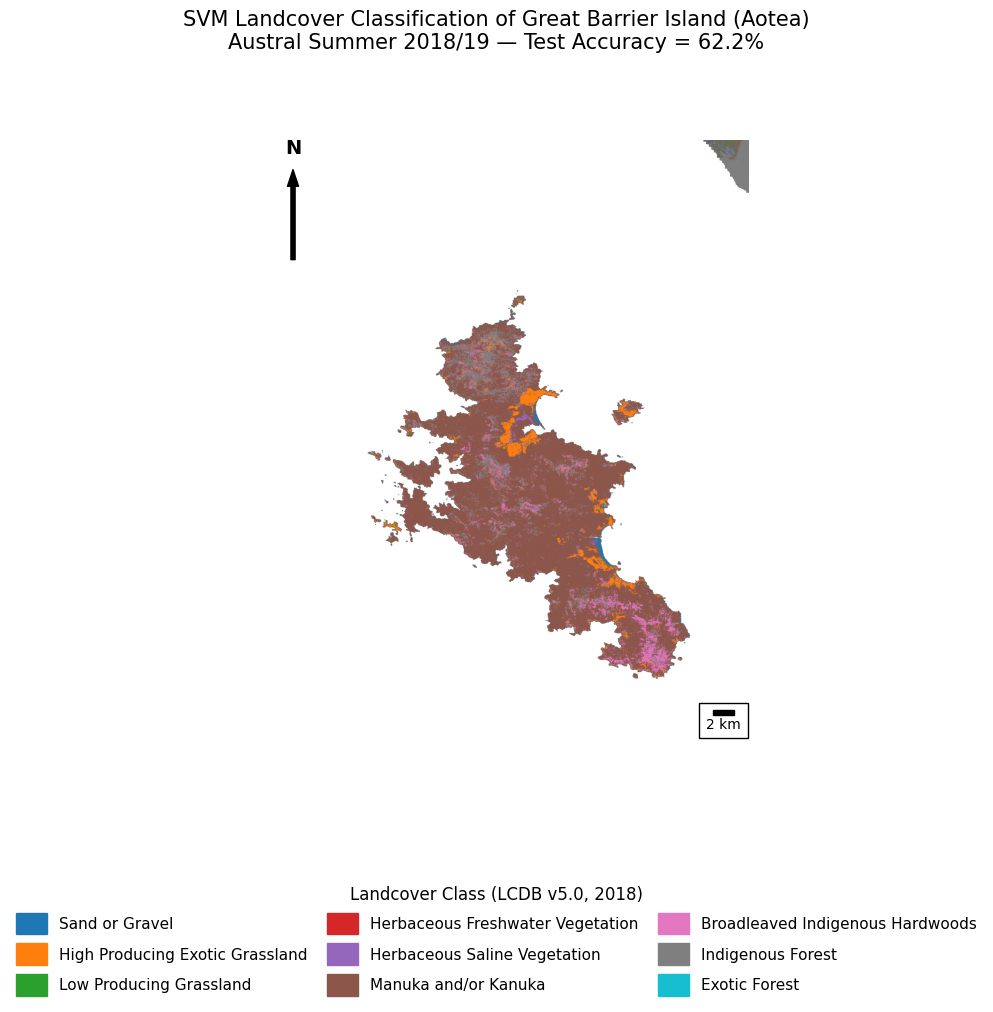

In [73]:
# Plotting
arr_gbi_masked = ma.masked_where(arr_gbi == 0, arr_gbi)

fig, ax = plt.subplots(figsize=(10, 10))

im = ax.imshow(arr_gbi_masked, cmap=cmap_gbi, norm=norm_gbi)
ax.axis('off')

fig.suptitle(
    'SVM Landcover Classification of Great Barrier Island (Aotea)\n'
    f'Austral Summer 2018/19 — Test Accuracy = {test_accuracy_gbi_final:.1%}',
    fontsize=15, y=0.98
)

legend_patches = [mpatches.Patch(color=palette_gbi[i], label=class_names_gbi[i]) for i in range(len(class_ids_gbi))]
legend = fig.legend(
    handles=legend_patches, loc='lower center', ncol=3,
    bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=11,
    title='Landcover Class (LCDB v5.0, 2018)',
    handlelength=2.0, handleheight=1.8, labelspacing=0.6, columnspacing=1.3
)
legend.get_title().set_fontsize(12)

# North arrow
ax.annotate('', xy=(0.05, 0.95), xycoords='axes fraction',
            xytext=(0.05, 0.80), textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=3, headwidth=8))
ax.text(0.05, 0.97, 'N', transform=ax.transAxes,
        fontsize=14, fontweight='bold', ha='center', va='bottom')

km_per_pixel = 20 / 1000
bar_length_km = 2
bar_length_px = bar_length_km / km_per_pixel

scalebar = AnchoredSizeBar(
    ax.transData, bar_length_px, f'{bar_length_km} km',
    loc='lower right', pad=0.5, color='black', frameon=True,
    size_vertical=arr_gbi_masked.shape[0] * 0.008,
    fontproperties=fm.FontProperties(size=10)
)
ax.add_artist(scalebar)

plt.subplots_adjust(top=0.85, bottom=0.25)
plt.savefig('great_barrier_island_svm_classification.png', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
unique, counts = np.unique(arr_gbi[arr_gbi != 0], return_counts=True)  # exclude nodata/water
total_land_pixels = counts.sum()

for val, count in zip(unique, counts):
    class_name = class_names_gbi[class_ids_gbi.index(val)]
    pct = 100 * count / total_land_pixels
    print(f"{class_name} (class {val}): {count} pixels ({pct:.1f}% of land)")

Sand or Gravel (class 5): 12692 pixels (1.4% of land)
High Producing Exotic Grassland (class 12): 48393 pixels (5.2% of land)
Low Producing Grassland (class 13): 2167 pixels (0.2% of land)
Herbaceous Saline Vegetation (class 15): 3138 pixels (0.3% of land)
Manuka and/or Kanuka (class 17): 700584 pixels (75.3% of land)
Broadleaved Indigenous Hardwoods (class 18): 56333 pixels (6.1% of land)
Indigenous Forest (class 20): 107580 pixels (11.6% of land)


In [ ]:
# 75.3% of classified land area was assigned to Manuka/Kanuka - substantially higher than would
# be expected given the class's true prevalence on the island (its LCDB training samples made up
# ~51% of the training set). This likely reflects residual class-imbalance bias: even after
# hyperparameter tuning, the model still favours its dominant training class in areas of spectral
# ambiguity, particularly where Manuka/Kanuka and Indigenous Forest overlap ecologically as
# different successional stages of the same vegetation community.